![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

Wiadomo, że pierwsze cyfry transakcji finansowych podlegają rozkładowi Benforda. W przypadku, gdy tak nie jest można podejrzewać, że dochodzido oszustw finansowych w badanym obszarze. Przy pomocy testu zgodności $\chi^2$ sprawdź czy dostarczone dane podlegają wspomnianemu rozkładowi: $$P(i)=log_{10}\left(1 + \frac{1}{i} \right)$$

In [1]:
import scipy.stats as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Wczytanie danych

In [2]:
df = pd.read_csv("creditcard.csv") # import danych do obiektu DataFrame
print(df.columns) # wypisanie nazw kolumn
df.head() # wypisanie kilku początkowych wierszy danych

Index(['Amount'], dtype='object')


,Amount
0,149.62
1,2.69
2,378.66
3,123.50
4,69.99


Sprawdzenie czy w danych są wartości NaN

In [3]:
len(df) ==  df.count()

Amount    True
dtype: bool

Ekstrakcja danych w postaci tablicy numpy.array

In [4]:
x = df["Amount"].to_numpy() # ekstrakcja danych

Wybranie pierwszych cyfr każdej liczby określającej wysokość transakcji oraz odrzucenie zer

In [5]:
# 1. zamiana liczb typu float na tekst
# 2. zwrócenie pierwszego znaku z kadej liczby w formacie tekstowym i zamiana jej na liczbę typu int
# 3. filtorwanie wyników i zwrócenie tylko cyfr (liczb) większych od zera (usunięcie zer ze zbioru danych)
# 4. utworzenie obiektu np.array ze zwróconego iteratora
d = np.fromiter(filter(lambda x: x>0 ,map(lambda x: int(x[0]),map(str,x) )),dtype=int)

Znalezienie wszystkich unikalnych cyfr i obliczenie częstości ich występowania w tablicy d

In [6]:
(i,ni) = np.unique(d,return_counts=True)
pi = ni/sum(ni)

print(i)
print(ni)
print(pi)

[1 2 3 4 5 6 7 8 9]
[100455  42357  27930  23222  18535  14081  13771  12740  14912]
[0.37482789 0.15804674 0.10421525 0.08664828 0.06915967 0.05254046
 0.05138375 0.04753678 0.05564117]


Wykres otrzymanych częstości występowania cyfr

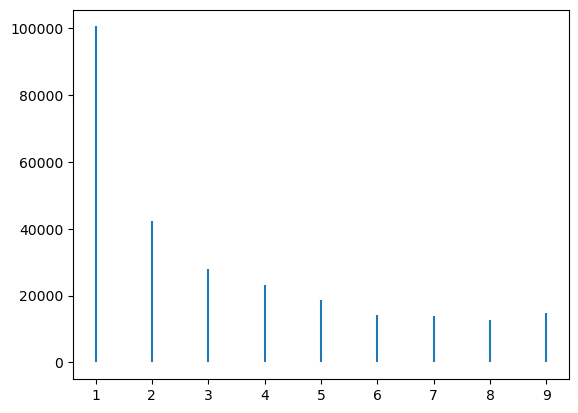

In [7]:
plt.vlines(i,0,ni)
pass

Utworzenie instancji rozkładu Benforda w celu wykonania analizy

In [8]:
rozkladBenforda = st.rv_discrete(values=(i,np.log10(1+1/i)))

Wykres porównujący częstości występowania cufr w próbie i częstości występowania cyfr zgodnie z rozkładem benforda

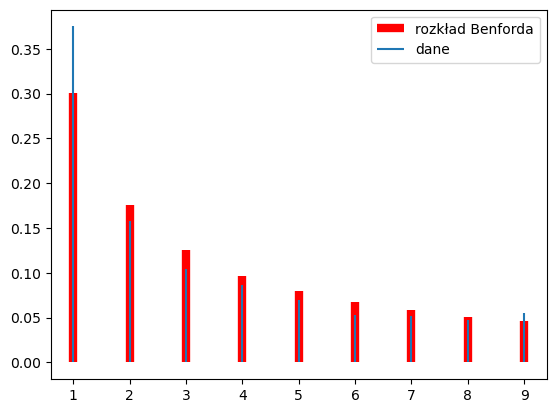

In [9]:
plt.vlines(i,0,rozkladBenforda.pmf(i),color="red",linewidth=6)
plt.vlines(i,0,pi)
plt.legend(["rozkład Benforda","dane"])
pass

Obliczenie statystyki testowej $$\chi_t^2=\sum_{j=1}^{j=k} \frac{(n_j-n_{t,j})^2}{n_{t,j}}$$ gdzie $n_j$ jest częstością obserwowaną w $j$-tej klasie, $n_{t,j}$ jest częstością teoretyczną, $k$ oznacza liczbę klas (z uwzględnieniem połączenia klas), natomiast $\chi_t^2$ jest statystyką testową.

In [10]:
nt = rozkladBenforda.pk * sum(ni) # liczebności teoretyczne
chi2t = sum((ni-nt)**2/nt) # statystyka testowa

Obliczenie p-wartości jako $p_v=1-F(\chi_t^2)$

In [11]:
k = len(i) # liczba klas = liczba cyfr z wyłączeniem zera
m = 0 # brak parametrów rozkładu oszacowanych na podstawie próby
df = k-m-1 # liczba stopni swobody
rozkladChi2 = st.chi2(df)
pvalue = 1 - rozkladChi2.cdf(chi2t)
print("pwartosc = {}, statystyka testowa = {}".format(pvalue,chi2t))

pwartosc = 0.0, statystyka testowa = 8569.84533526973


Hipotezę zerową mówiącą o identyczności rozkładów należy odrzucić. Oznacza to, że próba nie pochodzi z populacji podlegającej rozkładowi Benforda.

#### Użycie funkcji przeprowadzającej test $\chi^2$ z biblioteki scipy.stats.

In [12]:
st.chisquare(ni,nt)

Power_divergenceResult(statistic=8569.84533526973, pvalue=0.0)